# Liver Cancer Gene Expression Analysis
**Team 3: Sai Karthik, Makayla Phillips, Shreya Krishnan**

**Research Question:** *What genes play the most important role in determining risk of hepatic cancer, and how can expression levels of these genes be used to inform diagnosis of liver cancer?*

Dataset: GSE263786

Github link: https://github.com/sa1K/BME-357-Final-Project

## 1. Read in Data and Understand Data Structure

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("BME 357 Project Data")

# Local TPM-normalized expression matrix (Entrez gene IDs, GRCh38.p13)
expr_path = DATA_DIR / "GSE263786_norm_counts_TPM_GRCh38.p13_NCBI.tsv"
df = pd.read_csv(expr_path, sep="\t", index_col=0)
df.index = df.index.astype(str)  # Entrez IDs as strings for downstream symbol mapping
print("Expression matrix shape:", df.shape)

# Metadata: local CSV (Sample, Description). Disease state from Description.
meta_raw = pd.read_csv(DATA_DIR / "metadata_gse263786.csv")
meta_raw["disease_state"] = np.where(
    meta_raw["Description"].str.contains("Normal Liver", case=False, na=False),
    "Normal", "Disease",
)
meta_df = meta_raw.set_index("Sample")[["disease_state"]].reindex(df.columns)

print("\nDisease distribution:")
print(meta_df["disease_state"].value_counts(dropna=False))
print("\nFinal shapes:")
print("Expression:", df.shape)
print("Metadata:", meta_df.shape)


Expression matrix shape: (39376, 231)

Disease distribution:
disease_state
Disease    207
Normal      24
Name: count, dtype: int64

Final shapes:
Expression: (39376, 231)
Metadata: (231, 1)


## 2. Data Preprocessing
Inspect missingness, apply mean imputation, standard scaling, PCA feature selection, correlation matrix, and histograms of top correlated features.

Missing values per gene (top 10):
Series([], dtype: int64)

Total genes with missing values: 0
Total samples with missing values: 0


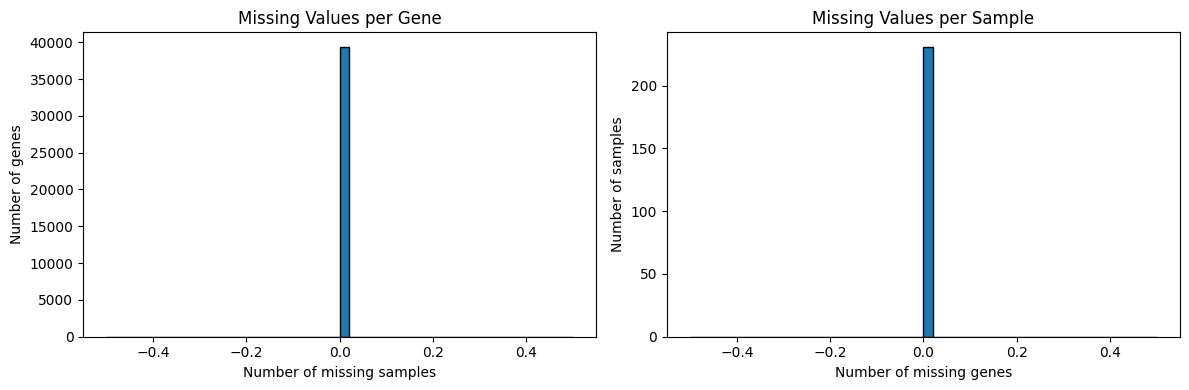

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Inspect missingness
missing_per_gene = df.isnull().sum(axis=1)
missing_per_sample = df.isnull().sum(axis=0)
print("Missing values per gene (top 10):")
print(missing_per_gene[missing_per_gene > 0].sort_values(ascending=False).head(10))
print(f"\nTotal genes with missing values: {(missing_per_gene > 0).sum()}")
print(f"Total samples with missing values: {(missing_per_sample > 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(missing_per_gene, bins=50, edgecolor='black')
axes[0].set_title('Missing Values per Gene')
axes[0].set_xlabel('Number of missing samples')
axes[0].set_ylabel('Number of genes')
axes[1].hist(missing_per_sample, bins=50, edgecolor='black')
axes[1].set_title('Missing Values per Sample')
axes[1].set_xlabel('Number of missing genes')
axes[1].set_ylabel('Number of samples')
plt.tight_layout()
plt.show()

In [3]:
# Mean imputation
df_imputed = df.fillna(df.mean(axis=1).to_dict())
df_imputed = df_imputed.fillna(0)  # any all-NaN rows
print(f"Remaining missing values after imputation: {df_imputed.isnull().sum().sum()}")

# Filter low-expression genes (TPM threshold)
min_tpm, min_samples = 1.0, 10
gene_mask = (df_imputed > min_tpm).sum(axis=1) >= min_samples
df_filtered = df_imputed.loc[gene_mask]
print(f"Genes after filtering (TPM>{min_tpm} in >={min_samples} samples): {df_filtered.shape[0]}")

# Standard scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered.T).T,
    index=df_filtered.index,
    columns=df_filtered.columns
)
print(f"Scaled data shape: {df_scaled.shape}")


Remaining missing values after imputation: 0
Genes after filtering (TPM>1.0 in >=10 samples): 18325
Scaled data shape: (18325, 231)


In [4]:
from pybiomart import Server

# Convert NCBI Entrez Gene IDs to HGNC Symbols via BioMart
entrez_ids = df_filtered.index.astype(str).tolist()

server = Server(host="http://www.ensembl.org")
dataset = server.marts["ENSEMBL_MART_ENSEMBL"].datasets["hsapiens_gene_ensembl"]
result = dataset.query(attributes=["entrezgene_id", "hgnc_symbol"])
result.columns = ["entrezgene_id", "hgnc_symbol"]
result = result.dropna(subset=["entrezgene_id"])
result["entrezgene_id"] = result["entrezgene_id"].astype(int).astype(str)

mapping = result[result["hgnc_symbol"].fillna("").str.len() > 0].drop_duplicates("entrezgene_id")
mapping_dict = dict(zip(mapping["entrezgene_id"], mapping["hgnc_symbol"]))

# Map Entrez IDs to symbols (fall back to the Entrez ID if no mapping exists)
new_index = [mapping_dict.get(eid, eid) for eid in entrez_ids]

# Collapse duplicate symbols by keeping the row with highest mean expression
temp_df = df_filtered.copy()
temp_df["symbol"] = new_index
temp_df["mean_expr"] = temp_df.drop(columns=["symbol"]).mean(axis=1)
temp_df = temp_df.sort_values("mean_expr", ascending=False)
temp_df = temp_df[~temp_df["symbol"].duplicated(keep="first")]
temp_df = temp_df.drop(columns=["mean_expr"]).set_index("symbol")

df_filtered = temp_df
print(f"Genes after Entrez-to-symbol conversion: {df_filtered.shape[0]}")
print(f"Genes with HGNC symbols: {sum(1 for g in df_filtered.index if not g.isdigit())}")
print(f"Sample gene names: {df_filtered.index[:10].tolist()}")

# Re-apply standard scaling with new index
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered.T).T,
    index=df_filtered.index,
    columns=df_filtered.columns
)
print(f"Scaled data shape: {df_scaled.shape}")


Genes after Entrez-to-symbol conversion: 18252
Genes with HGNC symbols: 15552
Sample gene names: ['ALB', 'MT-CO3', 'MT-CO1', 'MT-TS1', '4574', 'MT-ATP6', 'HP', 'MT-CO2', 'MT-ND4', 'APOA2']
Scaled data shape: (18252, 231)


In [5]:
# PCA for feature selection
from sklearn.decomposition import PCA

X = df_scaled.T.values  # samples x genes
pca_full = PCA()
pca_full.fit(X)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Number of PCs to retain 90% variance: {n_components_90}")

# Identify top contributing genes from PCA loadings
pca_fit = PCA(n_components=n_components_90)
X_pca = pca_fit.fit_transform(X)

# Gene importance = sum of absolute loadings across retained PCs
loadings = np.abs(pca_fit.components_)  # (n_components x n_genes)
gene_importance = loadings.sum(axis=0)
gene_importance_df = pd.DataFrame({
    'gene': df_scaled.index,
    'pca_importance': gene_importance
}).sort_values('pca_importance', ascending=False)

# Select top genes by PCA importance
n_top_genes = 2000
top_pca_genes = gene_importance_df.head(n_top_genes)['gene'].tolist()
df_selected = df_scaled.loc[top_pca_genes]
print(f"Genes selected via PCA feature selection: {df_selected.shape[0]}")

Number of PCs to retain 90% variance: 52
Genes selected via PCA feature selection: 2000


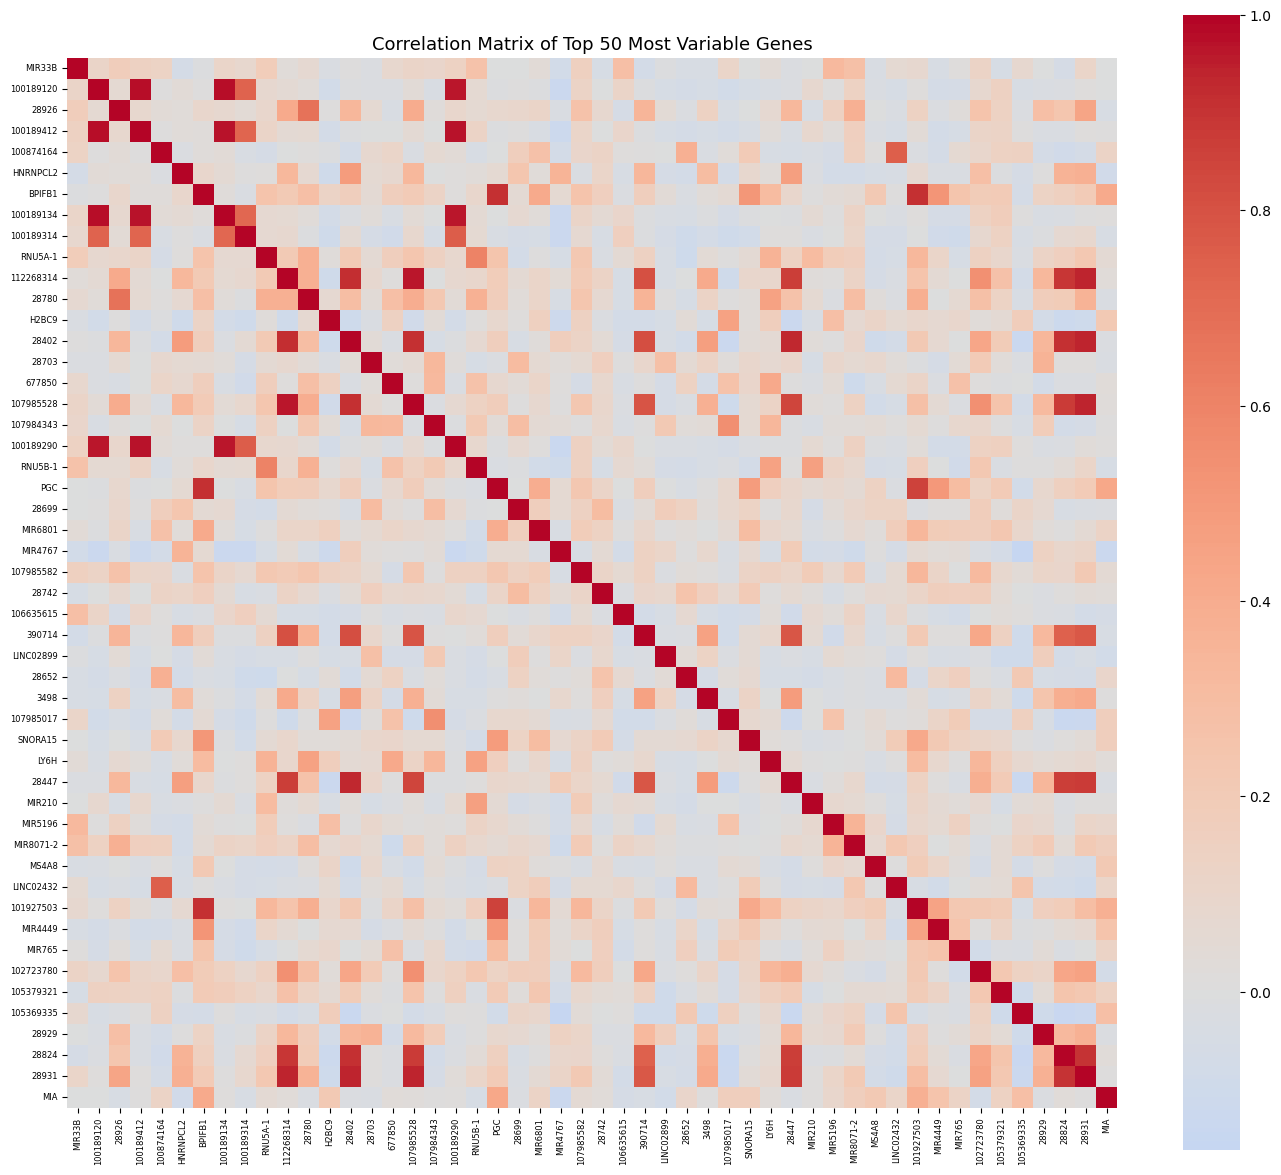

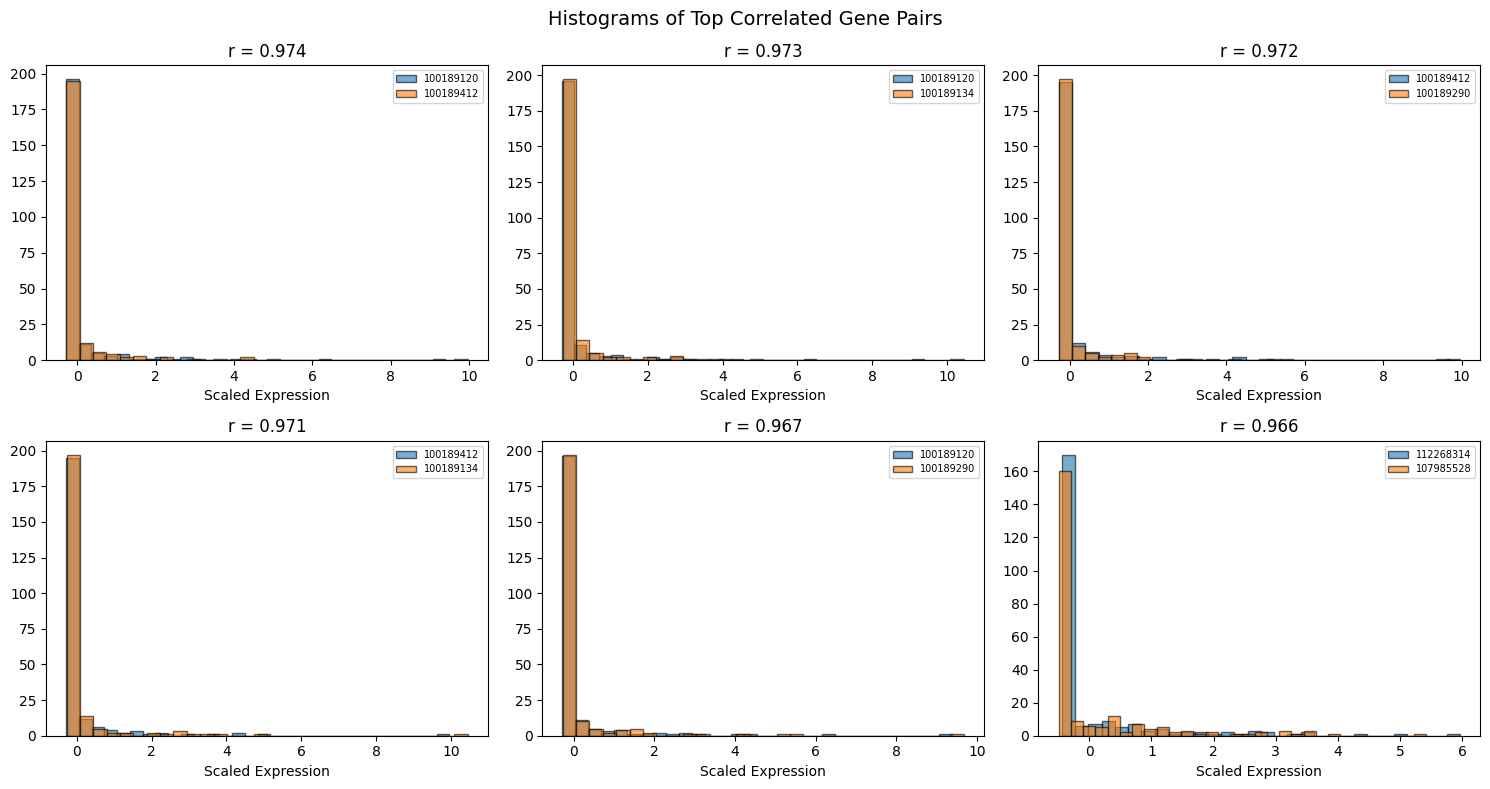

In [6]:
# Correlation matrix of top 50 most variable selected genes
gene_variance = df_selected.var(axis=1).sort_values(ascending=False)
top_var_genes = gene_variance.head(50).index
corr_matrix = df_selected.loc[top_var_genes].T.corr()

plt.figure(figsize=(14, 12))
ax = sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
                 xticklabels=True, yticklabels=True,
                 linewidths=0, square=True)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)
plt.title('Correlation Matrix of Top 50 Most Variable Genes', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Histograms of top correlated gene pairs
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_pairs = corr_upper.stack().abs().sort_values(ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, ((gene1, gene2), corr_val) in enumerate(top_pairs.items()):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df_selected.loc[gene1], bins=30, alpha=0.6, label=gene1, edgecolor='black')
    ax.hist(df_selected.loc[gene2], bins=30, alpha=0.6, label=gene2, edgecolor='black')
    ax.set_title(f'r = {corr_val:.3f}')
    ax.legend(fontsize=7)
    ax.set_xlabel('Scaled Expression')
plt.suptitle('Histograms of Top Correlated Gene Pairs', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Unsupervised Learning
PCA to reduce dimensionality (retaining 90% variance), scatter plot visualization, K-means clustering of genes with elbow method.

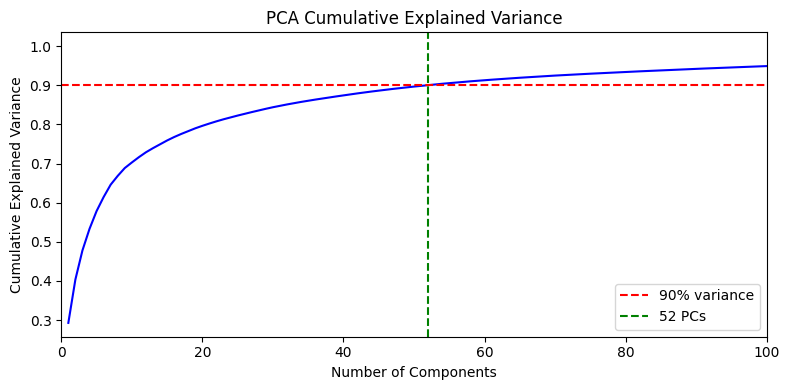

PCA-reduced data shape: (231, 52)


In [7]:
# PCA visualization (already computed above)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} PCs')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.xlim(0, min(100, len(cumulative_var)))
plt.tight_layout()
plt.show()

print(f"PCA-reduced data shape: {X_pca.shape}")

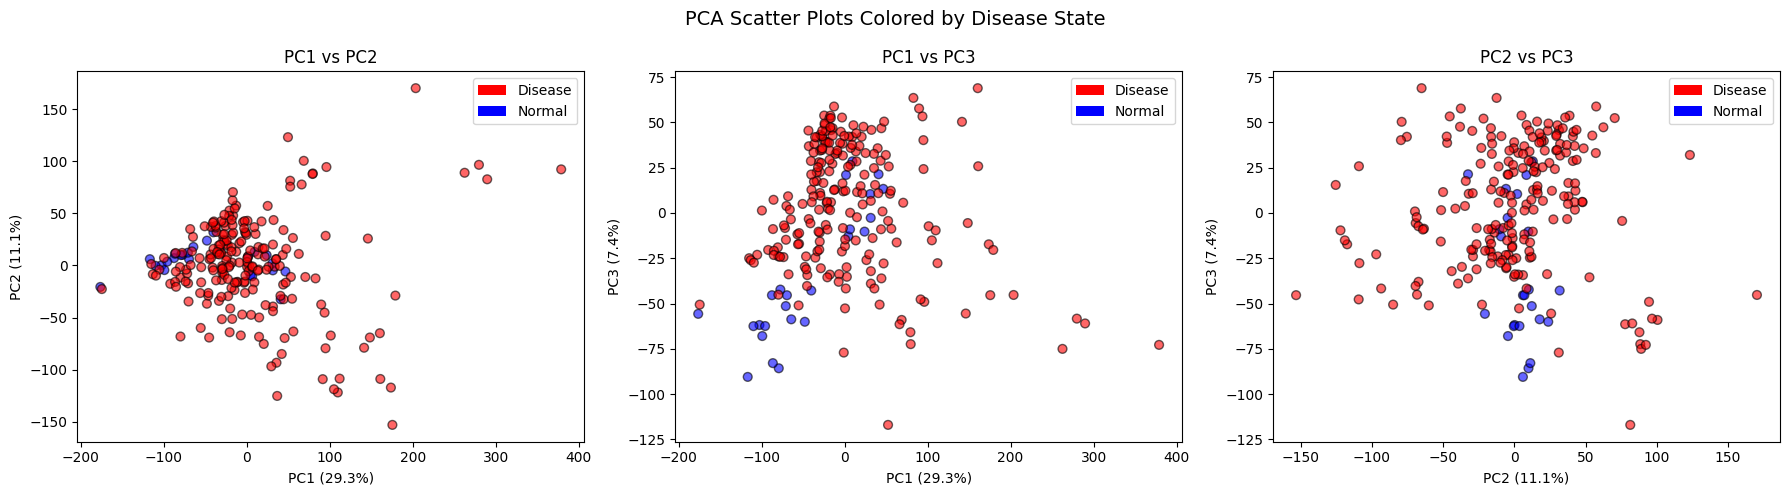

In [8]:
# PCA scatter plots colored by disease state
from matplotlib.patches import Patch

labels = meta_df.loc[df_scaled.columns, 'disease_state'].values
colors = ['red' if l == 'Disease' else 'blue' for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[0].set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PC1 vs PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 2], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[1].set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)')
axes[1].set_title('PC1 vs PC3')

axes[2].scatter(X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[2].set_xlabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_ylabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)')
axes[2].set_title('PC2 vs PC3')

legend_elements = [Patch(facecolor='red', label='Disease'), Patch(facecolor='blue', label='Normal')]
for ax in axes:
    ax.legend(handles=legend_elements)
plt.suptitle('PCA Scatter Plots Colored by Disease State', fontsize=14)
plt.tight_layout()
plt.show()

Sample cluster sizes:
cluster
0    200
1     31
Name: count, dtype: int64


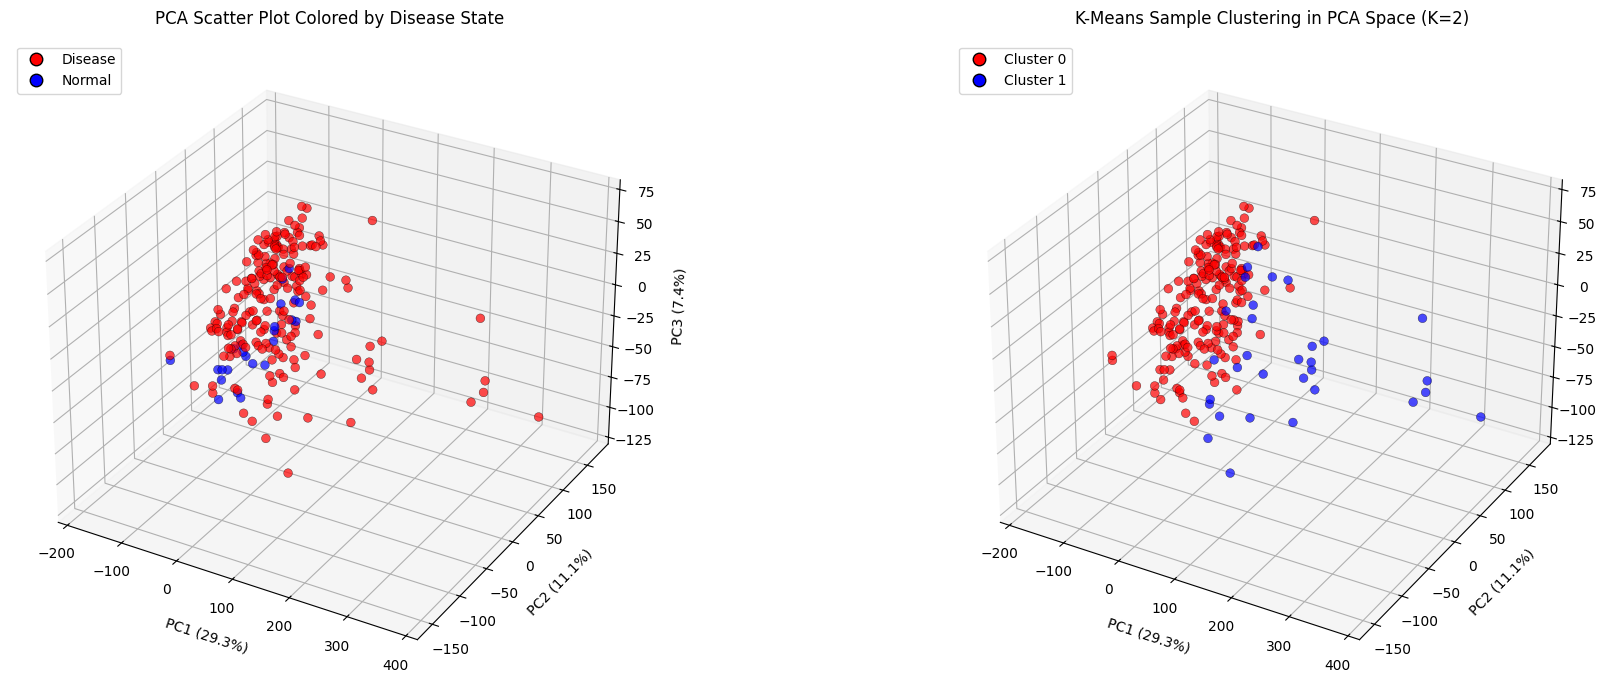

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Apply K-means to cluster samples (in PCA space)
# This can show us if the samples naturally separate
kmeans_samples = KMeans(n_clusters=2, random_state=42, n_init=10)
sample_cluster_labels = kmeans_samples.fit_predict(X_pca)

sample_clusters = pd.DataFrame({
    'sample': df_scaled.columns,
    'cluster': sample_cluster_labels
})

colors_cluster = ['red', 'blue']
cluster_colors = [colors_cluster[c] for c in sample_cluster_labels]

print("Sample cluster sizes:")
print(sample_clusters['cluster'].value_counts().sort_index())

colors = ['red' if l == 'Disease' else 'blue' for l in labels]

fig = plt.figure(figsize=(21, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=colors, alpha=0.7, edgecolors='k', s=40, linewidths=0.3)
ax1.set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)', labelpad=8)
ax1.set_ylabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)', labelpad=8)
ax1.set_zlabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)', labelpad=8)
ax1.set_title('PCA Scatter Plot Colored by Disease State', pad=12)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=9, markeredgecolor='k', label='Disease'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=9, markeredgecolor='k', label='Normal'),
]
ax1.legend(handles=legend_elements, loc='upper left')
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=cluster_colors, alpha=0.7, edgecolors='k', s=40, linewidths=0.3)
ax2.set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)', labelpad=8)
ax2.set_ylabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)', labelpad=8)
ax2.set_zlabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)', labelpad=8)
ax2.set_title('K-Means Sample Clustering in PCA Space (K=2)', pad=12)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_cluster[i],
                           markersize=9, markeredgecolor='k', label=f'Cluster {i}')
                   for i in range(2)]
ax2.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

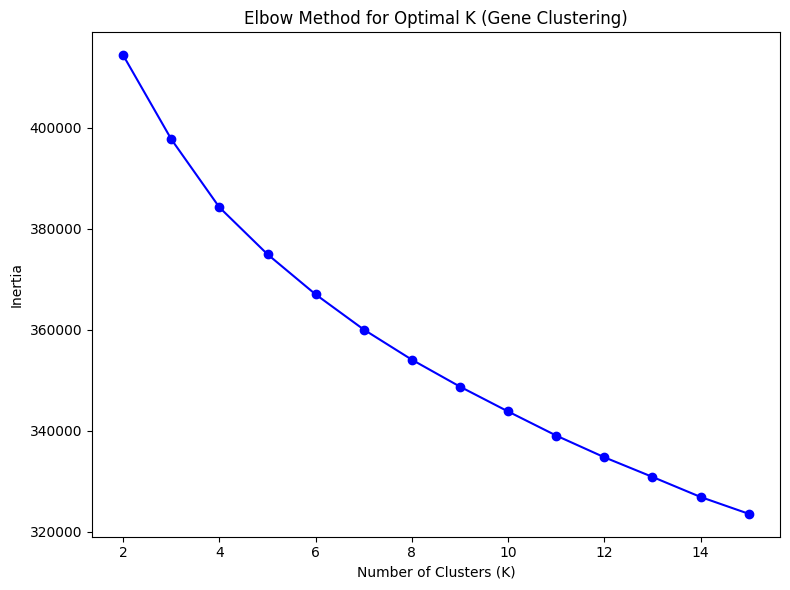

Optimal K selected: 5


In [10]:
from sklearn.cluster import KMeans

# K-means clustering of GENES based on expression profiles
# Genes as rows, samples as features
X_genes = df_selected.values  # (n_genes x n_samples)

# Elbow method
inertias = []
K_range = range(2, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_genes)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (Gene Clustering)')
plt.tight_layout()
plt.show()

# Select optimal K via maximum second derivative
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
optimal_k = list(K_range)[np.argmax(diffs2) + 2]
print(f"Optimal K selected: {optimal_k}")

Gene cluster sizes:
cluster
0     97
1    454
2    450
3    540
4    459
Name: count, dtype: int64


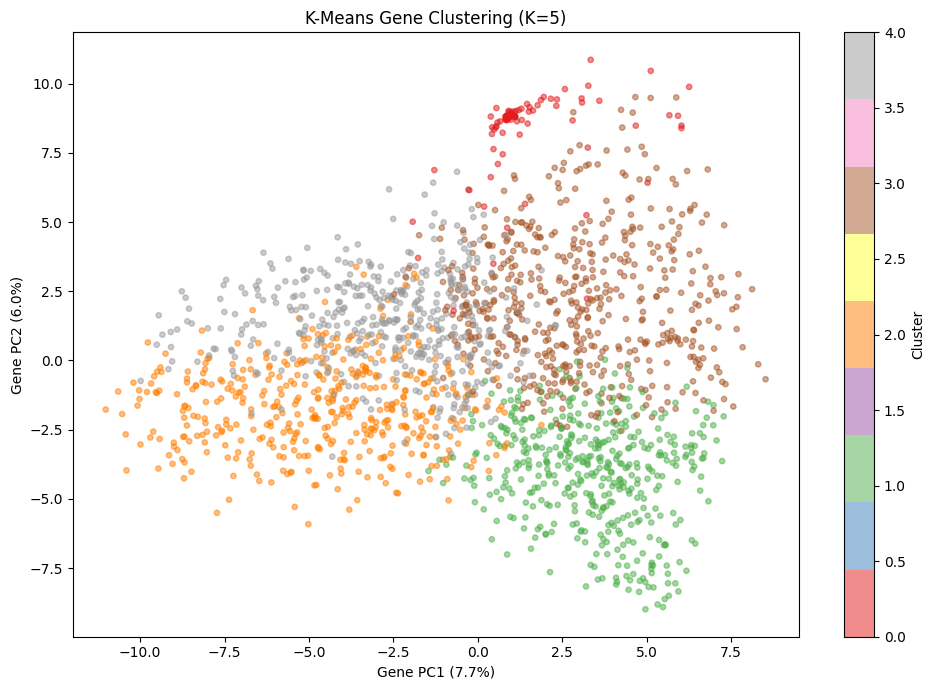

In [11]:
# Apply K-means to cluster genes
# This can show if there are certain genes that are co-expressed or with related expression patterns
kmeans_genes = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
gene_cluster_labels = kmeans_genes.fit_predict(X_genes)

gene_clusters = pd.DataFrame({
    'gene': df_selected.index,
    'cluster': gene_cluster_labels
})

print("Gene cluster sizes:")
print(gene_clusters['cluster'].value_counts().sort_index())

# Visualize gene clusters using PCA on genes
pca_gene_viz = PCA(n_components=2)
X_genes_2d = pca_gene_viz.fit_transform(X_genes)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_genes_2d[:, 0], X_genes_2d[:, 1],
                      c=gene_cluster_labels, cmap='Set1', alpha=0.5, s=15)
plt.xlabel(f'Gene PC1 ({pca_gene_viz.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Gene PC2 ({pca_gene_viz.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-Means Gene Clustering (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 4. Network Construction

### 4a. PPI Network from prebuilt adjacency (BME 357 Project Data/M_PPI.npz)

In [12]:
import networkx as nx
from scipy import sparse

# Load prebuilt PPI network
M_PPI = sparse.load_npz(DATA_DIR / "M_PPI.npz").tocsr()
ppi_name_arr = np.load(DATA_DIR / "PPI_name.npy", allow_pickle=True).squeeze()
ppi_names = np.array([str(np.asarray(n).item()) for n in ppi_name_arr])
ppi_idx = {g: i for i, g in enumerate(ppi_names)}

# Restrict to PCA-selected genes that exist in the PPI database
query_genes = df_selected.index.tolist()
ppi_genes_sel = [g for g in query_genes if g in ppi_idx]
print(f"PCA-selected genes mappable to PPI: {len(ppi_genes_sel)} / {len(query_genes)}")

ppi_pos = np.array([ppi_idx[g] for g in ppi_genes_sel])
M_PPI_sub = M_PPI[ppi_pos][:, ppi_pos].astype(np.uint8)
M_PPI_sub = M_PPI_sub.maximum(M_PPI_sub.T)  # treat as undirected
M_PPI_sub.setdiag(0)
M_PPI_sub.eliminate_zeros()

ppi_graph = nx.from_scipy_sparse_array(M_PPI_sub, edge_attribute="weight")
ppi_graph = nx.relabel_nodes(ppi_graph, {i: ppi_genes_sel[i] for i in range(len(ppi_genes_sel))})
ppi_graph.remove_nodes_from(list(nx.isolates(ppi_graph)))
print(f"PPI Network: {ppi_graph.number_of_nodes()} nodes, {ppi_graph.number_of_edges()} edges")

# PPI degree
ppi_degrees = dict(ppi_graph.degree())
ppi_degree_df = (
    pd.DataFrame(list(ppi_degrees.items()), columns=["gene", "ppi_degree"])
      .sort_values("ppi_degree", ascending=False)
)
print("\nTop 20 PPI hub genes:")
print(ppi_degree_df.head(20).to_string(index=False))


PCA-selected genes mappable to PPI: 866 / 2000
PPI Network: 860 nodes, 7524 edges

Top 20 PPI hub genes:
    gene  ppi_degree
     JUN         721
HSP90AA1         253
    ATF3         167
    CBX8         167
     FOS         157
    PTK6         152
   FAM9B         138
   NCOR1         134
    DAB1         133
 SLC6A20         130
  TWIST1         124
  S100A9         123
 FAM124B         119
  TFAP2C         118
    TGM2         117
    NAB2         115
    MDN1         114
    JUND         106
   RPS26         104
   CASP9         100


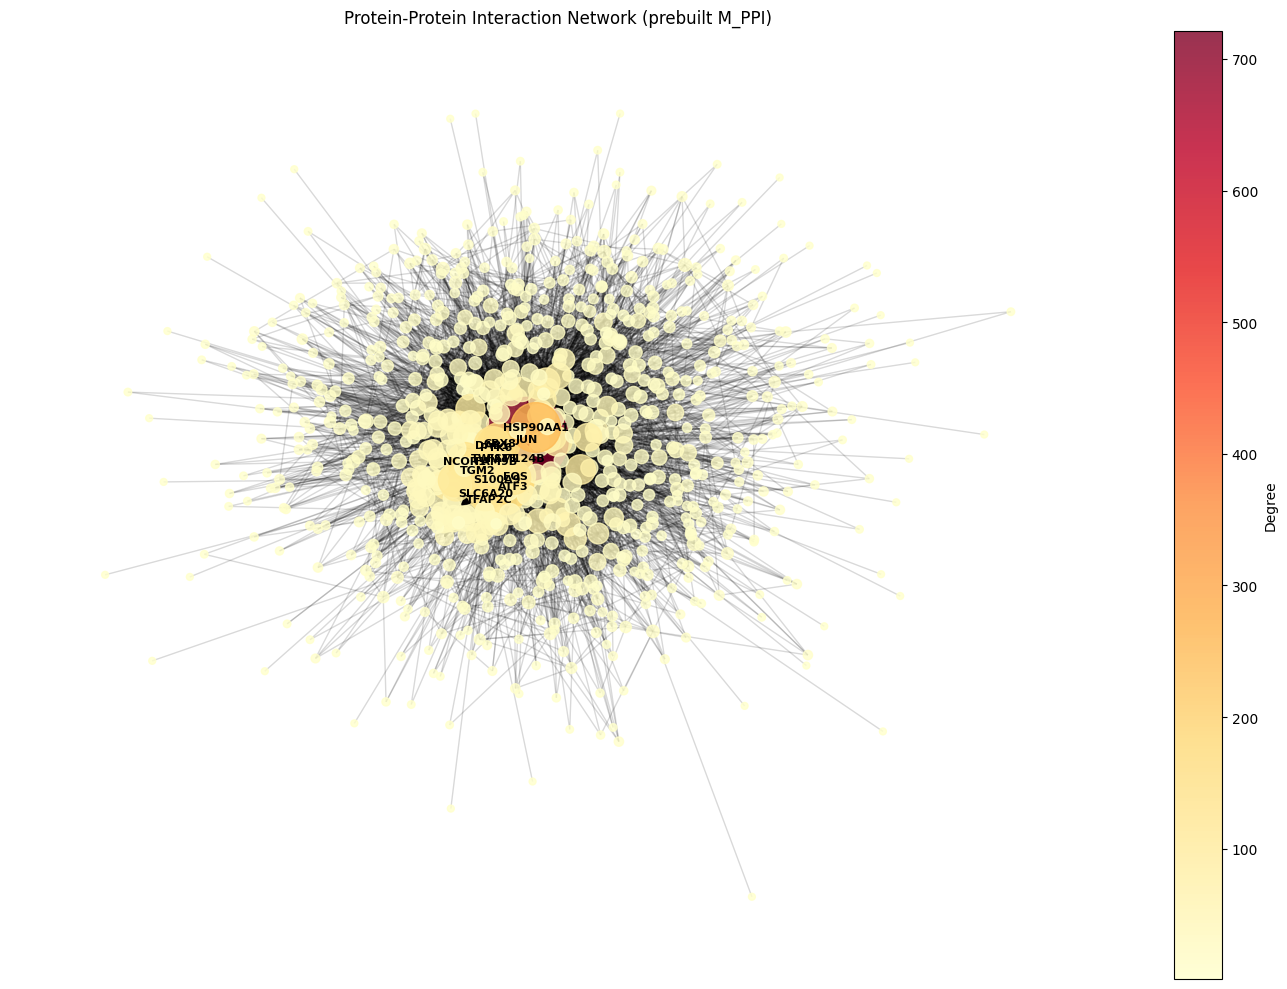

In [13]:
# Visualize PPI Network
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(ppi_graph, k=0.3, seed=42)

node_sizes = [ppi_degrees.get(n, 1) * 5 + 20 for n in ppi_graph.nodes()]
node_colors = [ppi_degrees.get(n, 0) for n in ppi_graph.nodes()]

nx.draw_networkx_edges(ppi_graph, pos, alpha=0.15)
nodes = nx.draw_networkx_nodes(ppi_graph, pos, node_size=node_sizes,
                                node_color=node_colors, cmap='YlOrRd', alpha=0.8)

top_hubs_ppi = ppi_degree_df.head(15)['gene'].tolist()
hub_labels = {n: n for n in ppi_graph.nodes() if n in top_hubs_ppi}
nx.draw_networkx_labels(ppi_graph, pos, labels=hub_labels, font_size=8, font_weight='bold')

plt.colorbar(nodes, label='Degree')
plt.title('Protein-Protein Interaction Network (prebuilt M_PPI)')
plt.axis('off')
plt.tight_layout()
plt.show()


### 4b. Gene Regulatory Network from prebuilt adjacency (BME 357 Project Data/M_GRN.npz)

In [14]:
from scipy import stats

# Load prebuilt GRN
M_GRN = sparse.load_npz(DATA_DIR / "M_GRN.npz").tocsr()
grn_name_arr = np.load(DATA_DIR / "GRN_name.npy", allow_pickle=True).squeeze()
grn_names = np.array([str(np.asarray(n).item()) for n in grn_name_arr])
grn_idx = {g: i for i, g in enumerate(grn_names)}

# Restrict to PCA-selected genes present in the GRN
grn_genes_sel = [g for g in df_selected.index if g in grn_idx]
print(f"PCA-selected genes mappable to GRN: {len(grn_genes_sel)} / {df_selected.shape[0]}")

grn_pos = np.array([grn_idx[g] for g in grn_genes_sel])
M_GRN_sub = M_GRN[grn_pos][:, grn_pos].astype(np.uint8)
M_GRN_sub = M_GRN_sub.maximum(M_GRN_sub.T)  # undirected for module/hub analysis
M_GRN_sub.setdiag(0)
M_GRN_sub.eliminate_zeros()

grn_graph = nx.from_scipy_sparse_array(M_GRN_sub, edge_attribute="weight")
grn_graph = nx.relabel_nodes(grn_graph, {i: grn_genes_sel[i] for i in range(len(grn_genes_sel))})
grn_graph.remove_nodes_from(list(nx.isolates(grn_graph)))
print(f"GRN: {grn_graph.number_of_nodes()} nodes, {grn_graph.number_of_edges()} edges")


PCA-selected genes mappable to GRN: 920 / 2000
GRN: 468 nodes, 997 edges


In [15]:
from networkx.algorithms.community import greedy_modularity_communities

# Module detection: greedy modularity on the prebuilt GRN
if grn_graph.number_of_edges() > 0:
    communities = list(greedy_modularity_communities(grn_graph))
else:
    communities = []

gene_to_module = {}
for mod_id, community in enumerate(communities, start=1):
    for gene in community:
        gene_to_module[gene] = mod_id

module_labels = np.array([gene_to_module.get(g, -1) for g in df_selected.index])
gene_modules = pd.DataFrame({"gene": df_selected.index, "module": module_labels})
n_modules = len(communities)
print(f"GRN modules detected: {n_modules}")

print("\nGenes per module (top 15):")
mod_counts = gene_modules[gene_modules["module"] != -1]["module"].value_counts().sort_index()
print(mod_counts.head(15))
print(f"Genes not in any GRN module: {(gene_modules['module'] == -1).sum()}")


GRN modules detected: 12

Genes per module (top 15):
module
1     95
2     82
3     62
4     51
5     46
6     29
7     29
8     28
9     26
10    12
11     6
12     2
Name: count, dtype: int64
Genes not in any GRN module: 1532


In [16]:
# Module-trait correlation
y_binary = (meta_df.loc[df_selected.columns, "disease_state"] == "Disease").astype(int).values

module_trait_corr = {}
for mod in sorted(m for m in gene_modules["module"].unique() if m != -1):
    mod_genes = gene_modules[gene_modules["module"] == mod]["gene"].values
    if len(mod_genes) < 2:
        continue
    mod_expr = df_selected.loc[mod_genes].T.values
    me = PCA(n_components=1).fit_transform(mod_expr).flatten()
    r, p = stats.pearsonr(me, y_binary)
    module_trait_corr[mod] = (r, p)

print("Module-Disease Trait Correlations (top 20 by |r|):")
print(f"{'Module':<10} {'Correlation':>12} {'p-value':>12} {'Genes':>8}")
ranked = sorted(module_trait_corr.items(), key=lambda x: abs(x[1][0]), reverse=True)
for mod, (r, p) in ranked[:20]:
    n_genes = (gene_modules["module"] == mod).sum()
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {mod:<8} {r:>12.4f} {p:>12.2e} {n_genes:>8} {sig}")

sig_modules = [mod for mod, (r, p) in module_trait_corr.items() if p < 0.05]
print(f"\nDisease-significant modules (p<0.05): {len(sig_modules)}/{len(module_trait_corr)}")


Module-Disease Trait Correlations (top 20 by |r|):
Module      Correlation      p-value    Genes
  1              0.3436     8.43e-08       95 ***
  6              0.3182     7.86e-07       29 ***
  5              0.2755     2.17e-05       46 ***
  8              0.2707     3.04e-05       28 ***
  3              0.2001     2.24e-03       62 **
  7              0.1793     6.30e-03       29 **
  4              0.1701     9.57e-03       51 **
  9              0.1524     2.05e-02       26 *
  2              0.1409     3.23e-02       82 *
  12             0.1371     3.74e-02        2 *
  11             0.0902     1.72e-01        6 
  10            -0.0766     2.46e-01       12 

Disease-significant modules (p<0.05): 10/12


K-Means vs GRN Module Agreement (2000 genes):
  Adjusted Rand Index (ARI): -0.0029
  Normalized Mutual Information (NMI): 0.0232


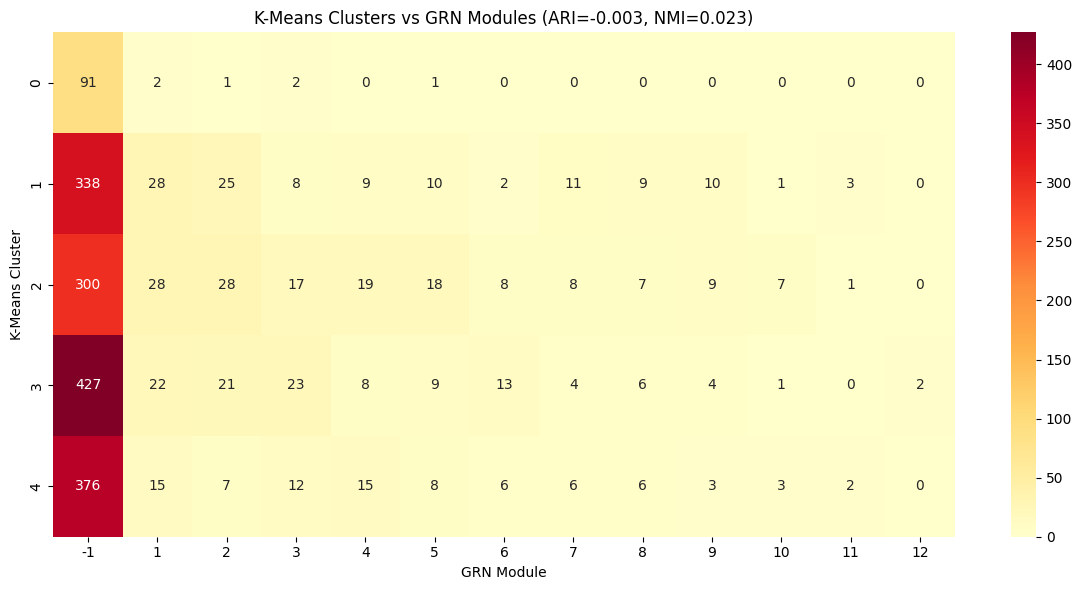

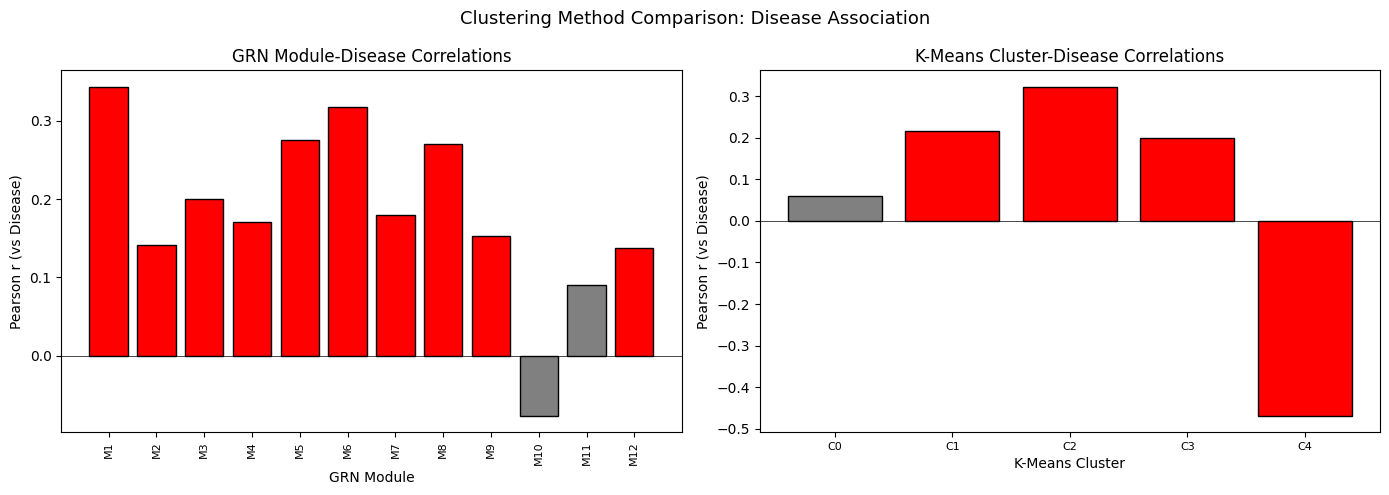


GRN disease-significant modules (p<0.05): 10/12
K-Means disease-significant clusters (p<0.05): 4/5


In [17]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Compare K-Means Clusters vs GRN Modules
kmeans_labels = gene_clusters.set_index('gene')['cluster']
grn_module_labels = gene_modules.set_index('gene')['module']

shared_genes = kmeans_labels.index.intersection(grn_module_labels.index)
km_aligned = kmeans_labels.loc[shared_genes].values
gm_aligned = grn_module_labels.loc[shared_genes].values

ari = adjusted_rand_score(km_aligned, gm_aligned)
nmi = normalized_mutual_info_score(km_aligned, gm_aligned)
print(f"K-Means vs GRN Module Agreement ({len(shared_genes)} genes):")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi:.4f}")

contingency = pd.crosstab(
    pd.Series(km_aligned, name='K-Means Cluster'),
    pd.Series(gm_aligned, name='GRN Module')
)

plt.figure(figsize=(12, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd')
plt.title(f'K-Means Clusters vs GRN Modules (ARI={ari:.3f}, NMI={nmi:.3f})')
plt.xlabel('GRN Module')
plt.ylabel('K-Means Cluster')
plt.tight_layout()
plt.show()

# Disease-trait correlation per K-means cluster
kmeans_trait_corr = {}
for cl in sorted(gene_clusters['cluster'].unique()):
    cl_genes = gene_clusters[gene_clusters['cluster'] == cl]['gene'].values
    cl_genes_in_data = [g for g in cl_genes if g in df_selected.index]
    if len(cl_genes_in_data) < 2:
        continue
    cl_expr = df_selected.loc[cl_genes_in_data].T.values
    eigengene = PCA(n_components=1).fit_transform(cl_expr).flatten()
    r, p = stats.pearsonr(eigengene, y_binary)
    kmeans_trait_corr[cl] = (r, p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grn_mods = sorted(module_trait_corr.keys())
grn_rs = [module_trait_corr[m][0] for m in grn_mods]
grn_ps = [module_trait_corr[m][1] for m in grn_mods]
colors_g = ['red' if p < 0.05 else 'gray' for p in grn_ps]
axes[0].bar(range(len(grn_mods)), grn_rs, color=colors_g, edgecolor='black')
axes[0].set_xticks(range(len(grn_mods)))
axes[0].set_xticklabels([f'M{m}' for m in grn_mods], fontsize=8, rotation=90)
axes[0].set_xlabel('GRN Module')
axes[0].set_ylabel('Pearson r (vs Disease)')
axes[0].set_title('GRN Module-Disease Correlations')
axes[0].axhline(0, color='black', linewidth=0.5)

km_cls = sorted(kmeans_trait_corr.keys())
km_rs = [kmeans_trait_corr[c][0] for c in km_cls]
km_ps = [kmeans_trait_corr[c][1] for c in km_cls]
colors_k = ['red' if p < 0.05 else 'gray' for p in km_ps]
axes[1].bar(range(len(km_cls)), km_rs, color=colors_k, edgecolor='black')
axes[1].set_xticks(range(len(km_cls)))
axes[1].set_xticklabels([f'C{c}' for c in km_cls], fontsize=8)
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('Pearson r (vs Disease)')
axes[1].set_title('K-Means Cluster-Disease Correlations')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.suptitle('Clustering Method Comparison: Disease Association', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nGRN disease-significant modules (p<0.05): {len(sig_modules)}/{len(module_trait_corr)}")
km_sig = [c for c, (r, p) in kmeans_trait_corr.items() if p < 0.05]
print(f"K-Means disease-significant clusters (p<0.05): {len(km_sig)}/{len(kmeans_trait_corr)}")


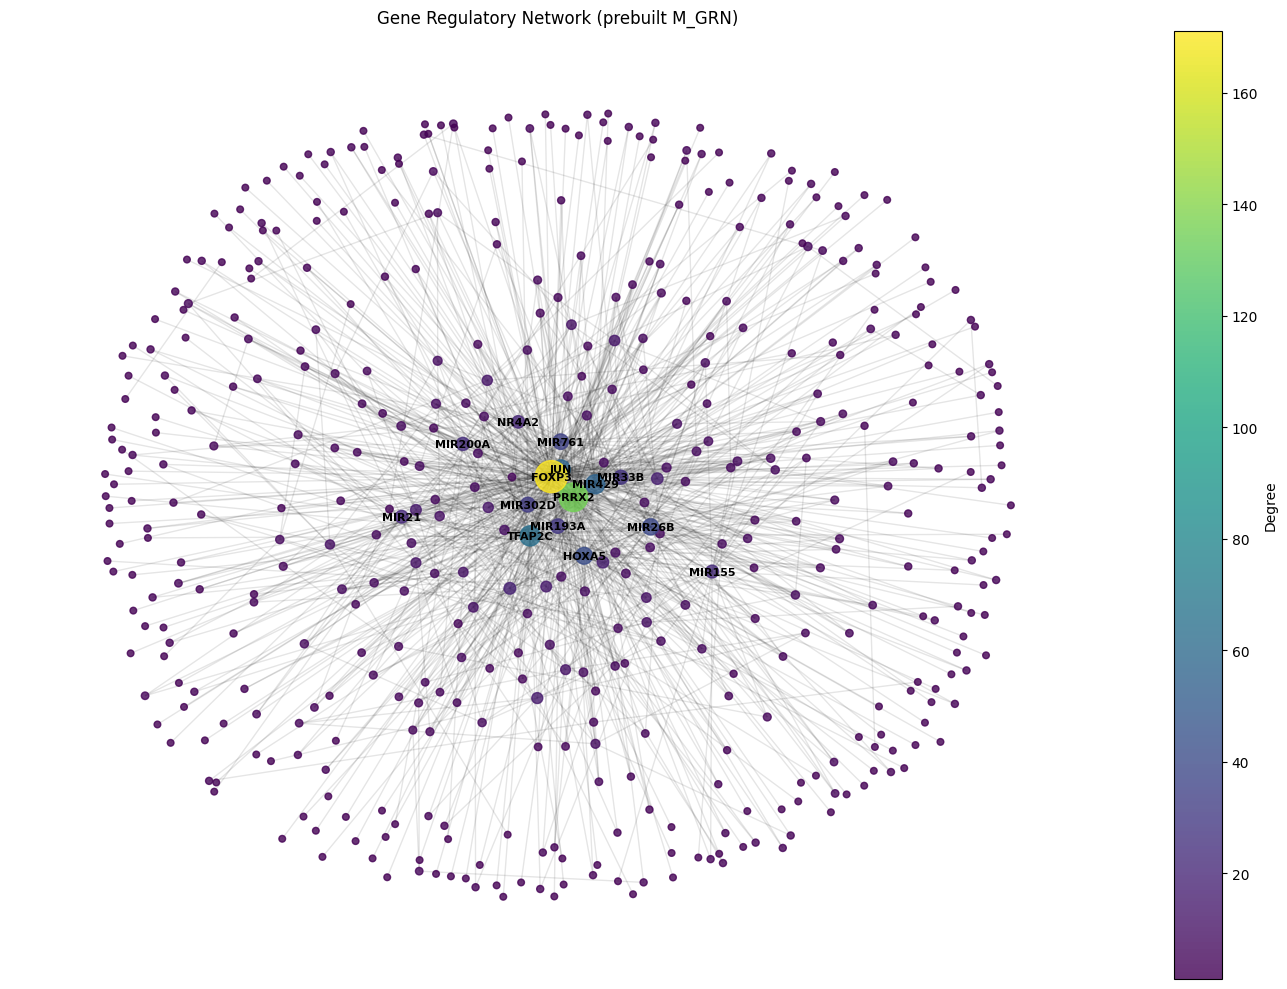

In [18]:
# Visualize GRN
plt.figure(figsize=(14, 10))
if grn_graph.number_of_nodes() > 0:
    pos_grn = nx.spring_layout(grn_graph, k=0.5, seed=42)
    grn_degrees = dict(grn_graph.degree())
    node_sizes_grn = [grn_degrees[n] * 3 + 20 for n in grn_graph.nodes()]
    node_colors_grn = [grn_degrees[n] for n in grn_graph.nodes()]

    nx.draw_networkx_edges(grn_graph, pos_grn, alpha=0.1)
    nodes_grn = nx.draw_networkx_nodes(grn_graph, pos_grn, node_size=node_sizes_grn,
                                        node_color=node_colors_grn, cmap='viridis', alpha=0.8)
    grn_degree_df = (
        pd.DataFrame(list(grn_degrees.items()), columns=['gene', 'grn_degree'])
          .sort_values('grn_degree', ascending=False)
    )
    top_hubs_grn = grn_degree_df.head(15)['gene'].tolist()
    hub_labels_grn = {n: n for n in grn_graph.nodes() if n in top_hubs_grn}
    nx.draw_networkx_labels(grn_graph, pos_grn, labels=hub_labels_grn, font_size=8, font_weight='bold')

    plt.colorbar(nodes_grn, label='Degree')
    plt.title('Gene Regulatory Network (prebuilt M_GRN)')
else:
    plt.text(0.5, 0.5, 'GRN is empty for selected genes.', ha='center', va='center', fontsize=14)
    plt.title('Gene Regulatory Network (empty)')
plt.axis('off')
plt.tight_layout()
plt.show()


## 5. Hub Gene Identification
Count connections in GRN and PPI, consolidate into a combined score, apply threshold.

Hub gene threshold (mean + 1 SD): 0.111
Number of hub genes identified: 53

Top 25 Hub Genes:
    gene  ppi_degree  grn_degree  combined_score
     JUN       721.0        57.0        1.333333
   FOXP3        33.0       171.0        1.045770
   PRRX2        13.0       135.0        0.807504
  TFAP2C       118.0        64.0        0.537931
HSP90AA1       253.0         9.0        0.403533
  MIR429         0.0        56.0        0.327485
    CBX8       167.0        12.0        0.301798
    ATF3       167.0         6.0        0.266710
   HOXA5         6.0        42.0        0.253936
     FOS       157.0         6.0        0.252841
    PTK6       152.0         4.0        0.234210
  MIR26B         0.0        39.0        0.228070
    DAB1       133.0         5.0        0.213706
  MIR761         0.0        35.0        0.204678
   NCOR1       134.0         3.0        0.203397
   FAM9B       138.0         2.0        0.203097
 FAM124B       119.0         5.0        0.194288
 SLC6A20       130.0    

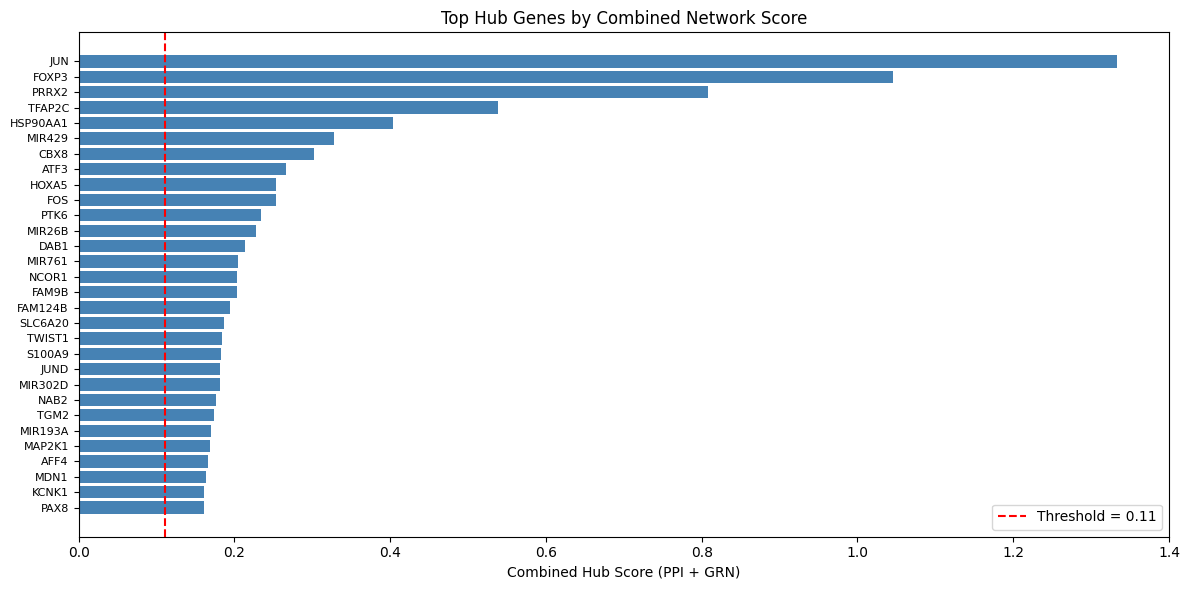

In [19]:
# Hub Gene Identification
# GRN degrees
if grn_graph.number_of_nodes() > 0:
    grn_degree_all = pd.DataFrame(list(dict(grn_graph.degree()).items()), columns=['gene', 'grn_degree'])
else:
    grn_degree_all = pd.DataFrame(columns=['gene', 'grn_degree'])

# Merge PPI + GRN degrees
hub_scores = pd.merge(ppi_degree_df, grn_degree_all, on='gene', how='outer').fillna(0)

# Normalize each to 0-1 and compute combined score
if hub_scores['ppi_degree'].max() > 0:
    hub_scores['ppi_norm'] = hub_scores['ppi_degree'] / hub_scores['ppi_degree'].max()
else:
    hub_scores['ppi_norm'] = 0
if hub_scores['grn_degree'].max() > 0:
    hub_scores['grn_norm'] = hub_scores['grn_degree'] / hub_scores['grn_degree'].max()
else:
    hub_scores['grn_norm'] = 0

hub_scores['combined_score'] = hub_scores['ppi_norm'] + hub_scores['grn_norm']
hub_scores = hub_scores.sort_values('combined_score', ascending=False)

# Threshold: mean + 1 SD
threshold = hub_scores['combined_score'].mean() + hub_scores['combined_score'].std()
hub_genes = hub_scores[hub_scores['combined_score'] >= threshold]['gene'].tolist()

print(f"Hub gene threshold (mean + 1 SD): {threshold:.3f}")
print(f"Number of hub genes identified: {len(hub_genes)}")
print(f"\nTop 25 Hub Genes:")
print(hub_scores.head(25)[['gene', 'ppi_degree', 'grn_degree', 'combined_score']].to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
top_n = min(30, len(hub_scores))
plt.barh(range(top_n), hub_scores.head(top_n)['combined_score'].values, color='steelblue')
plt.yticks(range(top_n), hub_scores.head(top_n)['gene'].values, fontsize=8)
plt.xlabel('Combined Hub Score (PPI + GRN)')
plt.title('Top Hub Genes by Combined Network Score')
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.2f}')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Train a logistic regression model based on Hub Genes

Hub genes identified : 53
Found in expression  : 53

  ROC-AUC  : 0.9926
  Accuracy : 0.9870

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      1.00      0.94        24
     Disease       1.00      0.99      0.99       207

    accuracy                           0.99       231
   macro avg       0.94      0.99      0.97       231
weighted avg       0.99      0.99      0.99       231


F-statistic p-values for hub genes:
              coef       p_value
JUN      -0.228713  4.969278e-01
FOXP3     0.450422  4.978556e-05
PRRX2     0.080487  1.083779e-01
TFAP2C    0.211578  2.879933e-03
HSP90AA1 -0.150498  2.708094e-01
MIR429    0.108843  8.513884e-02
CBX8      0.257694  1.131080e-04
ATF3     -0.307887  3.866368e-01
HOXA5    -0.181322  5.195156e-01
FOS       0.180118  7.747025e-02
PTK6     -0.244088  9.965999e-05
MIR26B   -0.074781  3.701046e-01
DAB1     -0.168877  3.876063e-01
MIR761    0.009150  1.786859e-01
NCOR1     0.176509  1.94

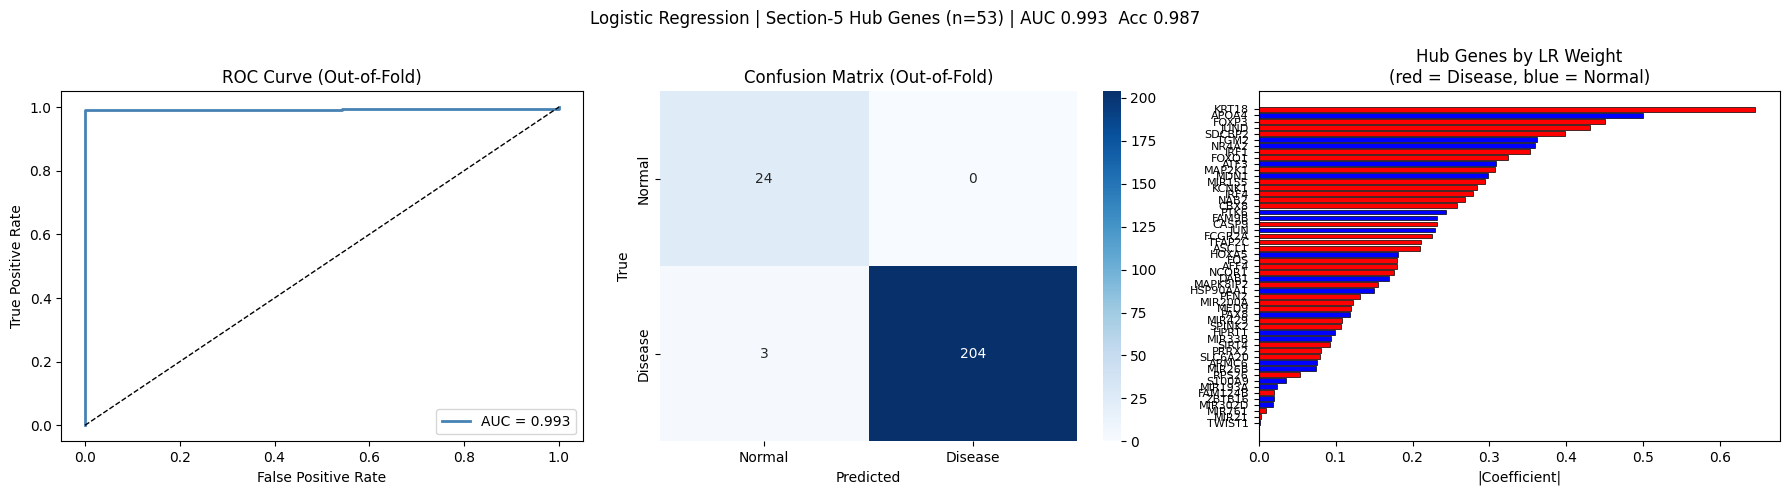

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             classification_report, roc_curve,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter to hub genes that are present in df_scaled
hub_genes_present = [g for g in hub_genes if g in df_scaled.index]
print(f"Hub genes identified : {len(hub_genes)}")
print(f"Found in expression  : {len(hub_genes_present)}")

X_lr = df_scaled.loc[hub_genes_present].T.values
y_lr = (meta_df.loc[df_selected.columns, "disease_state"] == "Disease").astype(int).values

# Logistic regression with standard scaling inside CV
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.1,
                              class_weight='balanced',
                              max_iter=1000,
                              random_state=42,
               ))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = cross_val_predict(pipe, X_lr, y_lr, cv=cv, method='predict_proba')[:, 1]
oof_preds = (oof_probs >= 0.5).astype(int)

auc = roc_auc_score(y_lr, oof_probs)
acc = accuracy_score(y_lr, oof_preds)

print(f"\n{'='*55}")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  Accuracy : {acc:.4f}")
print(f"{'='*55}")
print("\nClassification Report:")
print(classification_report(y_lr, oof_preds, target_names=["Normal", "Disease"]))

# Coefficients: which hub genes drive the decision?
pipe.fit(X_lr, y_lr)   # refit on full data for coefficient inspection
coefs = pd.Series(pipe.named_steps['lr'].coef_[0], index=hub_genes_present)
coefs_sorted = coefs.abs().sort_values(ascending=False)

# P-values for top 20 genes
pipe.fit(X_lr, y_lr)
coefs = pd.Series(pipe.named_steps['lr'].coef_[0], index=hub_genes_present)
coefs_sorted = coefs.abs().sort_values(ascending=False)

from sklearn.feature_selection import f_classif
X_lr_scaled = pipe.named_steps['scaler'].transform(X_lr)
f_stats, p_values = f_classif(X_lr_scaled, y_lr)
gene_pvals = pd.Series(p_values, index=hub_genes_present)
print("\nF-statistic p-values for hub genes:")
top20_genes = coefs_sorted.head(20).index
print(pd.DataFrame({'coef': coefs, 'p_value': gene_pvals}).to_string())

n_sig = (gene_pvals < 0.05).sum()
print(f"\nHub genes with F-statistic p < 0.05: {n_sig} / {len(hub_genes_present)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# ROC curve
fpr, tpr, _ = roc_curve(y_lr, oof_probs)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Out-of-Fold)')
axes[0].legend()
# Confusion matrix
cm = confusion_matrix(y_lr, oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Disease'],
            yticklabels=['Normal', 'Disease'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Out-of-Fold)')

# hub genes by absolute coefficient
top20 = coefs_sorted
colors = ['red' if coefs[g] > 0 else 'blue' for g in top20.index]
axes[2].barh(range(len(top20)), top20.values, color=colors, edgecolor='k', linewidth=0.5)
axes[2].set_yticks(range(len(top20)))
axes[2].set_yticklabels(top20.index, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('|Coefficient|')
axes[2].set_title('Hub Genes by LR Weight\n(red = Disease, blue = Normal)')

plt.suptitle(
    f'Logistic Regression | Section-5 Hub Genes (n={len(hub_genes_present)}) | '
    f'AUC {auc:.3f}  Acc {acc:.3f}',
    fontsize=12)
plt.tight_layout()
plt.show()

## 6. Hub Gene Identification: PCA vs UMAP vs t-SNE (each + K-means)
Compare three unsupervised pipelines for finding hub genes: cluster genes after PCA, after UMAP, and after t-SNE. For each method, rank hub genes from disease-associated clusters, evaluate diagnostic performance with logistic-regression cross-validation, and compare against the network-based hubs from Section 5.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans

# Shared setup for all unsupervised learning techniques
N_HUBS = 30
K_CLUSTERS = optimal_k  # reuse K from elbow

y_disease = (meta_df.loc[df_selected.columns, "disease_state"] == "Disease").astype(int).values
X_genes_full = df_selected.values  # genes x samples

# Per-gene disease |t-statistic| (used to rank within disease-associated clusters)
gene_tstats = np.array([
    abs(stats.ttest_ind(
        df_selected.iloc[g].values[y_disease == 1],
        df_selected.iloc[g].values[y_disease == 0],
        equal_var=False,
    ).statistic)
    for g in range(df_selected.shape[0])
])
gene_tstats = np.nan_to_num(gene_tstats, nan=0.0)


def hubs_from_clusters(cluster_labels, top_n=N_HUBS):
    #Pick top-n hub genes using proportional slot allocation across clusters.
    cluster_assoc = {}
    for c in np.unique(cluster_labels):
        members = np.where(cluster_labels == c)[0]
        if len(members) < 2:
            continue
        eg = PCA(n_components=1).fit_transform(X_genes_full[members].T).flatten()
        r, p = stats.pearsonr(eg, y_disease)
        cluster_assoc[c] = (abs(r), p, members)

    # Sort clusters by r descending
    sorted_clusters = sorted(cluster_assoc.items(), key=lambda x: x[1][0], reverse=True)
    total_r = sum(v[0] for _, v in sorted_clusters) or 1.0

    # Allocate slots per cluster proportional to r
    slots = {c: max(1, round(top_n * v[0] / total_r)) for c, v in sorted_clusters}

    selected, seen = [], set()
    for c, (r, p, members) in sorted_clusters:
        ranked = sorted(members, key=lambda i: -gene_tstats[i])
        for i in ranked[:slots[c]]:
            if i not in seen:
                selected.append(i)
                seen.add(i)

    # Fill any remaining slots from all members by t-stat
    if len(selected) < top_n:
        all_members = np.concatenate([v[2] for _, v in sorted_clusters])
        for i in sorted(all_members, key=lambda i: -gene_tstats[i]):
            if len(selected) >= top_n:
                break
            if i not in seen:
                selected.append(i)
                seen.add(i)

    return [df_selected.index[i] for i in selected[:top_n]], cluster_assoc


def evaluate_hubs(hub_genes):
    # 5-fold CV LogReg AUC using a single eigengene of hub-gene expression.
    X_hub = df_scaled.loc[hub_genes].T.values
    # Compress to 1 eigengene, avoids overfitting
    eigengene = PCA(n_components=1).fit_transform(X_hub)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = LogisticRegression(max_iter=5000, random_state=42, 
                            class_weight="balanced", C=0.1)
    aucs = cross_val_score(lr, eigengene, y_disease, cv=cv, scoring="roc_auc")
    accs = cross_val_score(lr, eigengene, y_disease, cv=cv, scoring="accuracy")
    return aucs, accs


# Method 1: PCA + K-means
pca_for_hubs = PCA(n_components=min(20, X_genes_full.shape[1] - 1), random_state=42)
X_genes_pca = pca_for_hubs.fit_transform(X_genes_full)
km_pca = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_pca = km_pca.fit_predict(X_genes_pca)

hubs_pca, assoc_pca = hubs_from_clusters(labels_pca)
aucs_pca, accs_pca = evaluate_hubs(hubs_pca)

print(f"PCA+K-means: {len(hubs_pca)} hubs")
print(f"  CV AUC:      {aucs_pca.mean():.4f} +/- {aucs_pca.std():.4f}")
print(f"  CV Accuracy: {accs_pca.mean():.4f} +/- {accs_pca.std():.4f}")
print(f"  Top 10 hubs: {hubs_pca[:10]}")


C:\Users\shrkr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


PCA+K-means: 30 hubs
  CV AUC:      1.0000 +/- 0.0000
  CV Accuracy: 0.9957 +/- 0.0087
  Top 10 hubs: ['GCHFR', 'DTX4', 'DNAJC17', '246182', 'GDNF', 'TSPAN10', '390732', 'LINC02177', 'TMEM238', 'FST']


In [22]:
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

# Method 2: UMAP + K-means
reducer = umap.UMAP(
    n_components=min(10, X_genes_full.shape[1] - 1),
    n_neighbors=15,
    min_dist=0.0,
    random_state=42,
)
X_genes_umap = reducer.fit_transform(X_genes_full)

km_umap = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_umap = km_umap.fit_predict(X_genes_umap)

hubs_umap, assoc_umap = hubs_from_clusters(labels_umap)
aucs_umap, accs_umap = evaluate_hubs(hubs_umap)

print(f"UMAP+K-means: {len(hubs_umap)} hubs")
print(f"  CV AUC:      {aucs_umap.mean():.4f} +/- {aucs_umap.std():.4f}")
print(f"  CV Accuracy: {accs_umap.mean():.4f} +/- {accs_umap.std():.4f}")
print(f"  Top 10 hubs: {hubs_umap[:10]}")

C:\Users\shrkr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\shrkr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP+K-means: 30 hubs
  CV AUC:      0.9951 +/- 0.0098
  CV Accuracy: 0.9698 +/- 0.0173
  Top 10 hubs: ['TNFSF11', 'MAD1L1', 'SCAT8', 'AS3MT', '105369571', 'DOP1B', 'EIF5AL1', 'PNMA6A', 'GPRIN3', 'ICAM4']


In [23]:
from sklearn.manifold import TSNE

# Method 3: t-SNE + K-means
n_genes = X_genes_full.shape[0]
tsne_perplexity = min(30, max(5, (n_genes - 1) // 3))
tsne = TSNE(
    n_components=3,
    perplexity=tsne_perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto",
)
X_genes_tsne = tsne.fit_transform(X_genes_full)

km_tsne = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_tsne = km_tsne.fit_predict(X_genes_tsne)

hubs_tsne, assoc_tsne = hubs_from_clusters(labels_tsne)
aucs_tsne, accs_tsne = evaluate_hubs(hubs_tsne)

print(f"t-SNE+K-means: {len(hubs_tsne)} hubs (perplexity={tsne_perplexity})")
print(f"  CV AUC:      {aucs_tsne.mean():.4f} +/- {aucs_tsne.std():.4f}")
print(f"  CV Accuracy: {accs_tsne.mean():.4f} +/- {accs_tsne.std():.4f}")
print(f"  Top 10 hubs: {hubs_tsne[:10]}")


t-SNE+K-means: 30 hubs (perplexity=30)
  CV AUC:      1.0000 +/- 0.0000
  CV Accuracy: 0.9913 +/- 0.0106
  Top 10 hubs: ['KRT18', 'GCHFR', 'VSIG2', 'HLA-L', 'SDCBP2', 'UGT2B28', 'DTX4', 'WNK4', 'DNAJC17', 'LINC00239']


In [24]:
# Compare PCA+K-means vs UMAP+K-means vs t-SNE+K-means (and network-determined hubs)
set_pca  = set(hubs_pca)
set_umap = set(hubs_umap)
set_tsne = set(hubs_tsne)
set_net = set(hub_genes)  # from network-degree hubs

def jaccard(a, b):
    return len(a & b) / max(len(a | b), 1)

method_sets = {
    "PCA+K-means":  set_pca,
    "UMAP+K-means": set_umap,
    "t-SNE+K-means": set_tsne,
    "Network": set_net,
}

print("Pairwise hub-gene Jaccard:")
names = list(method_sets)
print(f"  {'':<14} " + " ".join(f"{n:<14}" for n in names))
for a in names:
    row = [f"  {a:<14}"]
    for b in names:
        row.append(f"{jaccard(method_sets[a], method_sets[b]):<14.3f}")
    print(" ".join(row))

print()
print(f"Shared by PCA & UMAP & t-SNE: {sorted(set_pca & set_umap & set_tsne)}")
print(f"Shared by all four:           {sorted(set_pca & set_umap & set_tsne & set_net)}")

summary = pd.DataFrame({
    "method": ["PCA+K-means", "UMAP+K-means", "t-SNE+K-means"],
    "n_hubs": [len(hubs_pca), len(hubs_umap), len(hubs_tsne)],
    "cv_auc_mean": [aucs_pca.mean(), aucs_umap.mean(), aucs_tsne.mean()],
    "cv_auc_std": [aucs_pca.std(),  aucs_umap.std(),  aucs_tsne.std()],
    "cv_acc_mean": [accs_pca.mean(), accs_umap.mean(), accs_tsne.mean()],
    "cv_acc_std": [accs_pca.std(),  accs_umap.std(),  accs_tsne.std()],
    "overlap_with_network": [len(set_pca & set_net), len(set_umap & set_net), len(set_tsne & set_net)],
})
print("\n", summary.to_string(index=False))


Pairwise hub-gene Jaccard:
                 PCA+K-means    UMAP+K-means   t-SNE+K-means  Network       
  PCA+K-means    1.000          0.364          0.429          0.025         
  UMAP+K-means   0.364          1.000          0.500          0.025         
  t-SNE+K-means  0.429          0.500          1.000          0.037         
  Network        0.025          0.025          0.037          1.000         

Shared by PCA & UMAP & t-SNE: ['105369571', 'AS3MT', 'DOP1B', 'EIF5AL1', 'GDNF', 'GPR171', 'HLA-L', 'ICAM4', 'KRT18', 'LINC02015', 'MAD1L1', 'SCAT8', 'TNFSF11']
Shared by all four:           ['KRT18']

        method  n_hubs  cv_auc_mean  cv_auc_std  cv_acc_mean  cv_acc_std  overlap_with_network
  PCA+K-means      30     1.000000    0.000000     0.995652    0.008696                     2
 UMAP+K-means      30     0.995122    0.009756     0.969750    0.017256                     2
t-SNE+K-means      30     1.000000    0.000000     0.991304    0.010650                     3


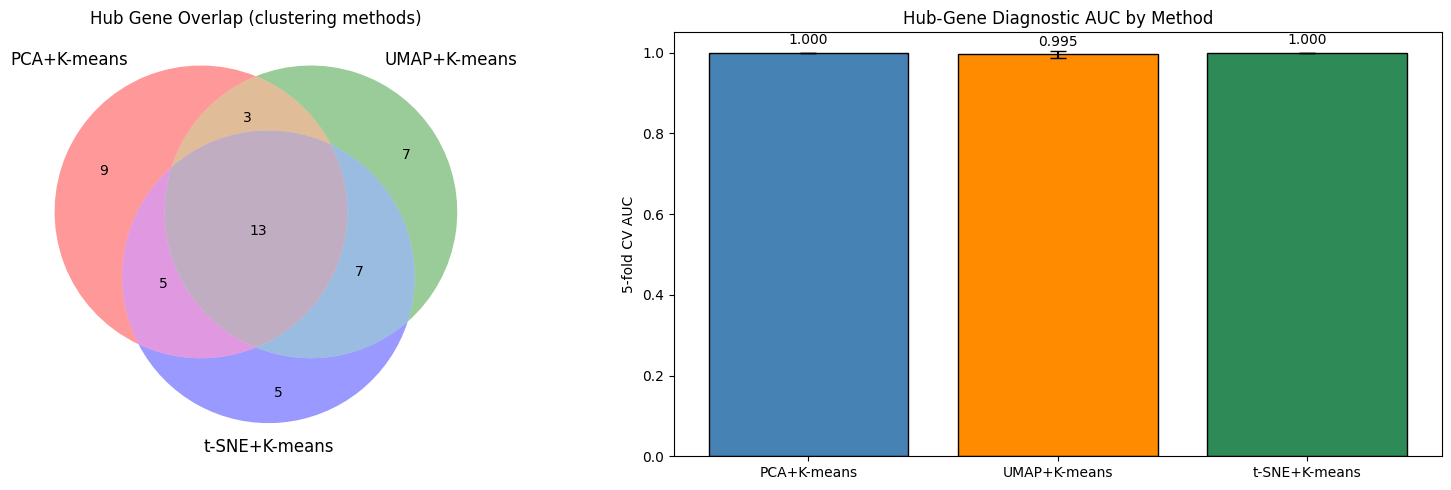

HUB GENE METHOD COMPARISON - SUMMARY
Genes analyzed: 2000  Samples: 231
Top-N hubs per method: 30

Network-based hubs (Section 5): 53
PCA+K-means hubs:               30  CV-AUC = 1.000 +/- 0.000
UMAP+K-means hubs:              30  CV-AUC = 0.995 +/- 0.010
t-SNE+K-means hubs:             30  CV-AUC = 1.000 +/- 0.000

Ranked by CV-AUC: PCA+K-means (1.0000) > t-SNE+K-means (1.0000) > UMAP+K-means (0.9951)


In [25]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Venn of three clustering-based hub sets
plt.sca(axes[0])
try:
    from matplotlib_venn import venn3
    venn3(
        [set_pca, set_umap, set_tsne],
        set_labels=("PCA+K-means", "UMAP+K-means", "t-SNE+K-means"),
    )
    axes[0].set_title("Hub Gene Overlap (clustering methods)")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib-venn"])
    from matplotlib_venn import venn3
    venn3(
        [set_pca, set_umap, set_tsne],
        set_labels=("PCA+K-means", "UMAP+K-means", "t-SNE+K-means"),
    )
    axes[0].set_title("Hub Gene Overlap (clustering methods)")

# AUC bar chart
methods = ["PCA+K-means", "UMAP+K-means", "t-SNE+K-means"]
auc_means = [aucs_pca.mean(), aucs_umap.mean(), aucs_tsne.mean()]
auc_stds = [aucs_pca.std(),  aucs_umap.std(),  aucs_tsne.std()]
colors = ["steelblue", "darkorange", "seagreen"]
axes[1].bar(methods, auc_means, yerr=auc_stds, capsize=6, color=colors, edgecolor="black")
axes[1].set_ylabel("5-fold CV AUC")
axes[1].set_title("Hub-Gene Diagnostic AUC by Method")
axes[1].set_ylim(0.0, 1.05)
for i, (m, s) in enumerate(zip(auc_means, auc_stds)):
    axes[1].text(i, m + 0.02, f"{m:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# Final summary
print("=" * 70)
print("HUB GENE METHOD COMPARISON - SUMMARY")
print("=" * 70)
print(f"Genes analyzed: {df_selected.shape[0]}  Samples: {df_selected.shape[1]}")
print(f"Top-N hubs per method: {N_HUBS}")
print(f"\nNetwork-based hubs (Section 5): {len(set_net)}")
print(f"PCA+K-means hubs:               {len(set_pca)}  CV-AUC = {aucs_pca.mean():.3f} +/- {aucs_pca.std():.3f}")
print(f"UMAP+K-means hubs:              {len(set_umap)}  CV-AUC = {aucs_umap.mean():.3f} +/- {aucs_umap.std():.3f}")
print(f"t-SNE+K-means hubs:             {len(set_tsne)}  CV-AUC = {aucs_tsne.mean():.3f} +/- {aucs_tsne.std():.3f}")
ranking = sorted(
    [("PCA+K-means", aucs_pca.mean()),
     ("UMAP+K-means", aucs_umap.mean()),
     ("t-SNE+K-means", aucs_tsne.mean())],
    key=lambda x: -x[1],
)
print(f"\nRanked by CV-AUC: " + " > ".join(f"{n} ({a:.4f})" for n, a in ranking))
print("=" * 70)


## 7. Biological Context: Pathway Enrichment of Hub Genes (gseapy/Enrichr)
Use `gseapy.enrichr` to query the hub-gene sets (network-based hubs from §5 and the three clustering-based hub sets from §6) against KEGG, MSigDB Hallmark, GO Biological Process, and Reactome libraries. This adds a pathway-level biological interpretation linking the data-driven hubs to HCC-relevant mechanisms (inflammation, ECM remodeling, heat-shock / proteostasis response).

In [26]:
try:
    import gseapy as gp
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gseapy"])
    import gseapy as gp

# Hub-gene sets to enrich
def filter_symbols(genes):
    """Keep only HGNC-style symbols (drop numeric-only Entrez fallbacks)."""
    return sorted({g for g in genes if isinstance(g, str) and not g.isdigit()})

hub_sets = {
    "Network (Section 5)": filter_symbols(hub_genes),
    "PCA+K-means":         filter_symbols(hubs_pca),
    "UMAP+K-means":        filter_symbols(hubs_umap),
    "t-SNE+K-means":       filter_symbols(hubs_tsne),
    "Union (all methods)": filter_symbols(set(hub_genes) | set(hubs_pca) | set(hubs_umap) | set(hubs_tsne)),
}

LIBRARIES = [
    "KEGG_2021_Human",
    "MSigDB_Hallmark_2020",
    "GO_Biological_Process_2023",
    "Reactome_2022",
]

# Reference background = all genes considered after filtering (HGNC symbols only)
background = filter_symbols(df_scaled.index.tolist())
print(f"Background (HGNC symbols, post-filter): {len(background)} genes")

enrich_results = {}
for set_name, genes in hub_sets.items():
    if len(genes) < 3:
        print(f"[skip] {set_name}: only {len(genes)} symbols")
        continue
    print(f"\n=== Enrichr: {set_name} ({len(genes)} genes) ===")
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=LIBRARIES,
        organism="homo sapiens",
        background=background,
        outdir=None,
        no_plot=True,
    )
    enrich_results[set_name] = enr.results

    top = (enr.results
              .sort_values("Adjusted P-value")
              .groupby("Gene_set", group_keys=False)
              .head(5))
    desired = ["Gene_set", "Term", "Overlap", "Adjusted P-value", "Combined Score", "Odds Ratio", "Genes"]
    cols = [c for c in desired if c in top.columns]
    print(top[cols].to_string(index=False))


Background (HGNC symbols, post-filter): 15552 genes

=== Enrichr: Network (Section 5) (53 genes) ===
                  Gene_set                                                                     Term  Adjusted P-value  Combined Score  Odds Ratio                                                                                                       Genes
GO_Biological_Process_2023   Positive Regulation Of Transcription By RNA Polymerase II (GO:0045944)          0.000034      112.190345    7.139332                                 JUN;TFAP2C;JUND;MED9;TWIST1;FOS;ASCL1;FOXP3;NR4A2;PAX8;IRF4;IRF1;ATF3;HOXA5
GO_Biological_Process_2023          Positive Regulation Of DNA-templated Transcription (GO:0045893)          0.000034       97.742311    6.236493                   JUN;MAP2K1;TFAP2C;JUND;ZBTB16;MED9;TWIST1;FOS;ASCL1;FOXP3;NR4A2;PAX8;IRF4;IRF1;ATF3;HOXA5
GO_Biological_Process_2023                   Regulation Of DNA-templated Transcription (GO:0006355)          0.000034       89.045442    

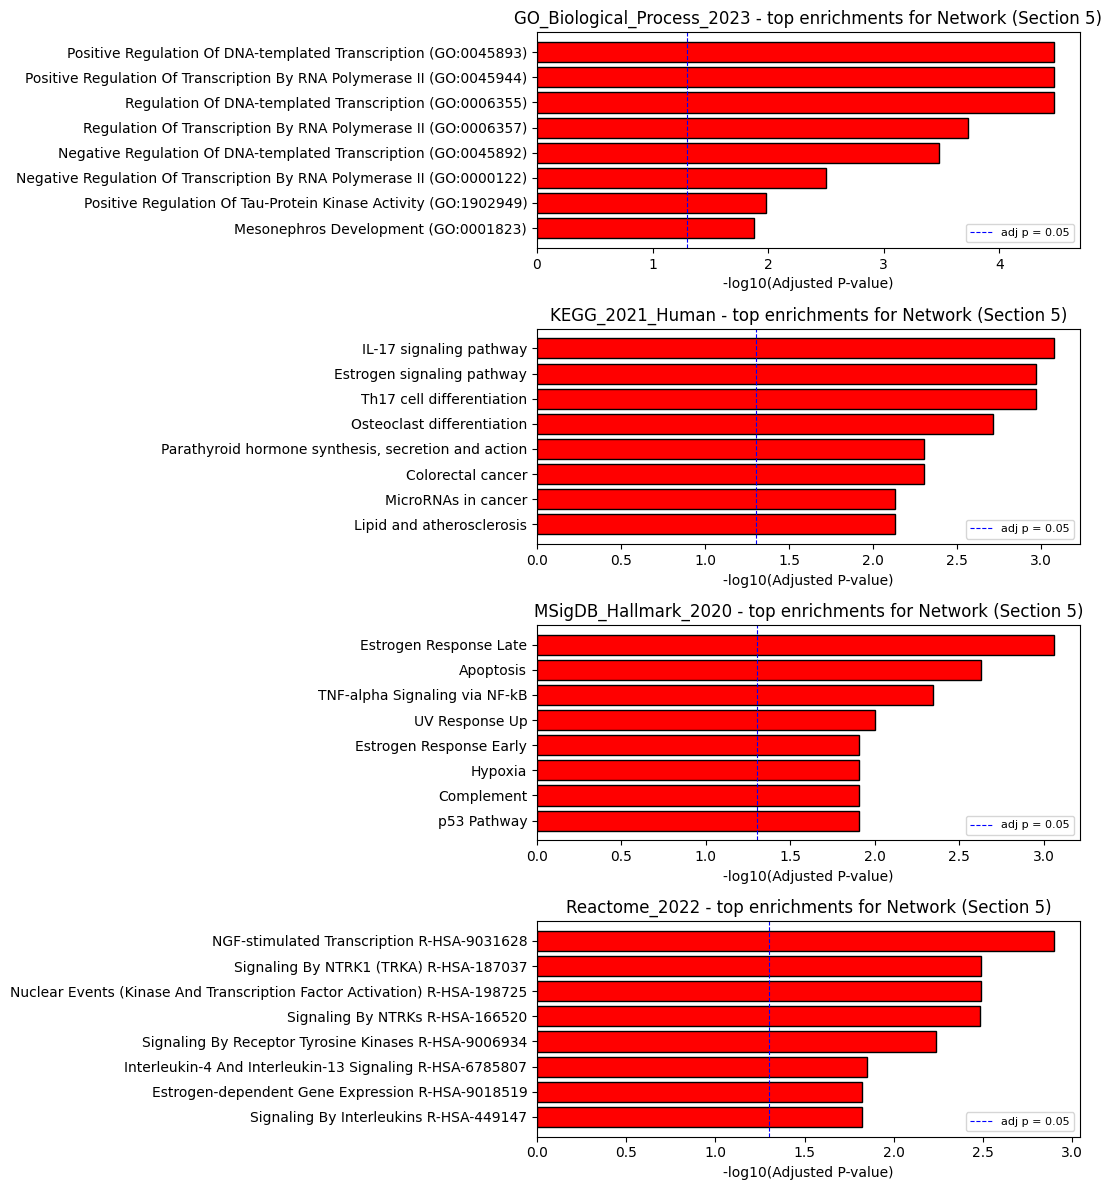


Top 3 enriched terms (any library) per hub-gene set:

Network (Section 5): 84 significant terms (adj p < 0.05)
  - Positive Regulation Of Transcription By RNA Polymerase II (GO:0045944)
  - Positive Regulation Of DNA-templated Transcription (GO:0045893)
  - Regulation Of DNA-templated Transcription (GO:0006355)

PCA+K-means: 0 significant terms (adj p < 0.05)
  - Regulation Of Morphogenesis Of A Branching Structure (GO:0060688)
  - Regulation Of Type I Interferon Production (GO:0032479)
  - Enteric Nervous System Development (GO:0048484)

UMAP+K-means: 5 significant terms (adj p < 0.05)
  - Regulation Of Monooxygenase Activity (GO:0032768)
  - Negative Regulation Of Extrinsic Apoptotic Signaling Pathway In Absence Of Ligand (GO:2001240)
  - Negative Regulation Of Signal Transduction In Absence Of Ligand (GO:1901099)

t-SNE+K-means: 0 significant terms (adj p < 0.05)
  - Regulation Of Type I Interferon Production (GO:0032479)
  - Regulation Of Sensory Perception (GO:0051931)
  - Regula

In [27]:
# Top enriched terms across libraries (Network hubs) for biological interpretation
focus_set = "Network (Section 5)"
if focus_set in enrich_results:
    res = enrich_results[focus_set].copy()
    res["-log10(adj p)"] = -np.log10(res["Adjusted P-value"].clip(lower=1e-300))

    top_per_lib = (res.sort_values("Adjusted P-value")
                      .groupby("Gene_set", group_keys=False)
                      .head(8))
    libs = top_per_lib["Gene_set"].unique()
    fig, axes = plt.subplots(len(libs), 1, figsize=(11, 3.0 * len(libs)))
    if len(libs) == 1:
        axes = [axes]
    for ax, lib in zip(axes, libs):
        sub = top_per_lib[top_per_lib["Gene_set"] == lib].sort_values("-log10(adj p)")
        colors = ["red" if p < 0.05 else "gray" for p in sub["Adjusted P-value"]]
        ax.barh(sub["Term"].str[:75], sub["-log10(adj p)"], color=colors, edgecolor="black")
        ax.axvline(-np.log10(0.05), color="blue", linestyle="--", linewidth=0.8, label="adj p = 0.05")
        ax.set_xlabel("-log10(Adjusted P-value)")
        ax.set_title(f"{lib} - top enrichments for {focus_set}")
        ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print(f"No results for {focus_set}; skipping plot.")

# --- Compact cross-method enrichment summary ---
def top_terms(df_enr, k=3):
    return (df_enr.sort_values("Adjusted P-value")
                  .head(k)["Term"].tolist())

print("\nTop 3 enriched terms (any library) per hub-gene set:")
for set_name, df_enr in enrich_results.items():
    sig = df_enr[df_enr["Adjusted P-value"] < 0.05]
    print(f"\n{set_name}: {len(sig)} significant terms (adj p < 0.05)")
    for t in top_terms(df_enr, 3):
        print(f"  - {t}")


## 8. Additional Extensions: Neural Network-based Disease Identification using Hub Genes
Train a 3-layer MLP on the 50 network hub genes from Section 5. 5-fold stratified cross-validation with weighted sampling to handle the Disease-Normal class imbalance.

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             classification_report, roc_curve,
                             confusion_matrix)
import numpy as np

# Data preparation: use the network hub genes from Section 5
X_nn = df_scaled.loc[hub_genes].T.values.astype(np.float32)
y_nn = y_disease.astype(np.int64)

print(f"Feature matrix : {X_nn.shape}  (samples x hub genes)")
print(f"Label distribution: Disease={y_nn.sum()}, Normal={len(y_nn)-y_nn.sum()}")

# Model definition
class HubGeneNet(nn.Module):
    # 3-layer MLP with batch-norm, dropout, and a binary output.
    def __init__(self, n_features, hidden1=64, hidden2=32, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

# Training helpers
def make_weighted_sampler(y_train):
    # Over-sample the minority class to counteract 207:24 imbalance.
    counts = np.bincount(y_train)
    weights = 1.0 / counts[y_train]
    return WeightedRandomSampler(torch.tensor(weights, dtype=torch.float32),
                                 num_samples=len(y_train), replacement=True)

def train_one_fold(X_tr, y_tr, X_va, y_va, epochs=300, lr=1e-3, batch_size=32):
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_va = sc.transform(X_va)

    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32)
    Xv = torch.tensor(X_va, dtype=torch.float32)
    yv = torch.tensor(y_va, dtype=torch.float32)

    sampler = make_weighted_sampler(y_tr)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, sampler=sampler)
    model = HubGeneNet(n_features=Xt.shape[1])
    pos_weight = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
                               dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, val_losses = [], []
    best_auc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        scheduler.step()
        train_losses.append(epoch_loss / len(y_tr))

        model.eval()
        with torch.no_grad():
            val_logits = model(Xv)
            val_loss = criterion(val_logits, yv).item()
            val_probs = torch.sigmoid(val_logits).numpy()
        val_losses.append(val_loss)

        auc = roc_auc_score(y_va, val_probs) if len(np.unique(y_va)) > 1 else 0.5
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xv)).numpy()
    return probs, (probs >= 0.5).astype(int), train_losses, val_losses

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_probs, all_preds, all_true = [], [], []
fold_aucs, fold_accs = [], []
all_train_losses, all_val_losses = [], []

print("\nTraining 5-fold CV...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_nn, y_nn)):
    probs, preds, tl, vl = train_one_fold(
        X_nn[tr_idx], y_nn[tr_idx], X_nn[va_idx], y_nn[va_idx])
    auc = roc_auc_score(y_nn[va_idx], probs) if len(np.unique(y_nn[va_idx])) > 1 else 0.5
    acc = accuracy_score(y_nn[va_idx], preds)
    fold_aucs.append(auc); fold_accs.append(acc)
    all_probs.extend(probs); all_preds.extend(preds); all_true.extend(y_nn[va_idx])
    all_train_losses.append(tl); all_val_losses.append(vl)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  Accuracy={acc:.4f}")

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true = np.array(all_true)

print(f"\n{'='*55}")
print(f"  Mean CV AUC      : {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}")
print(f"  Mean CV Accuracy : {np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}")
print(f"{'='*55}")
print("\nClassification Report (concatenated OOF predictions):")
print(classification_report(all_true, all_preds, target_names=["Normal", "Disease"]))

Feature matrix : (231, 53)  (samples x hub genes)
Label distribution: Disease=207, Normal=24

Training 5-fold CV...
  Fold 1: AUC=1.0000  Accuracy=0.8298
  Fold 2: AUC=1.0000  Accuracy=0.9783
  Fold 3: AUC=1.0000  Accuracy=0.9348
  Fold 4: AUC=1.0000  Accuracy=0.9130
  Fold 5: AUC=1.0000  Accuracy=0.7174

  Mean CV AUC      : 1.0000 +/- 0.0000
  Mean CV Accuracy : 0.8747 +/- 0.0923

Classification Report (concatenated OOF predictions):
              precision    recall  f1-score   support

      Normal       0.45      0.96      0.61        24
     Disease       0.99      0.86      0.93       207

    accuracy                           0.87       231
   macro avg       0.72      0.91      0.77       231
weighted avg       0.94      0.87      0.89       231



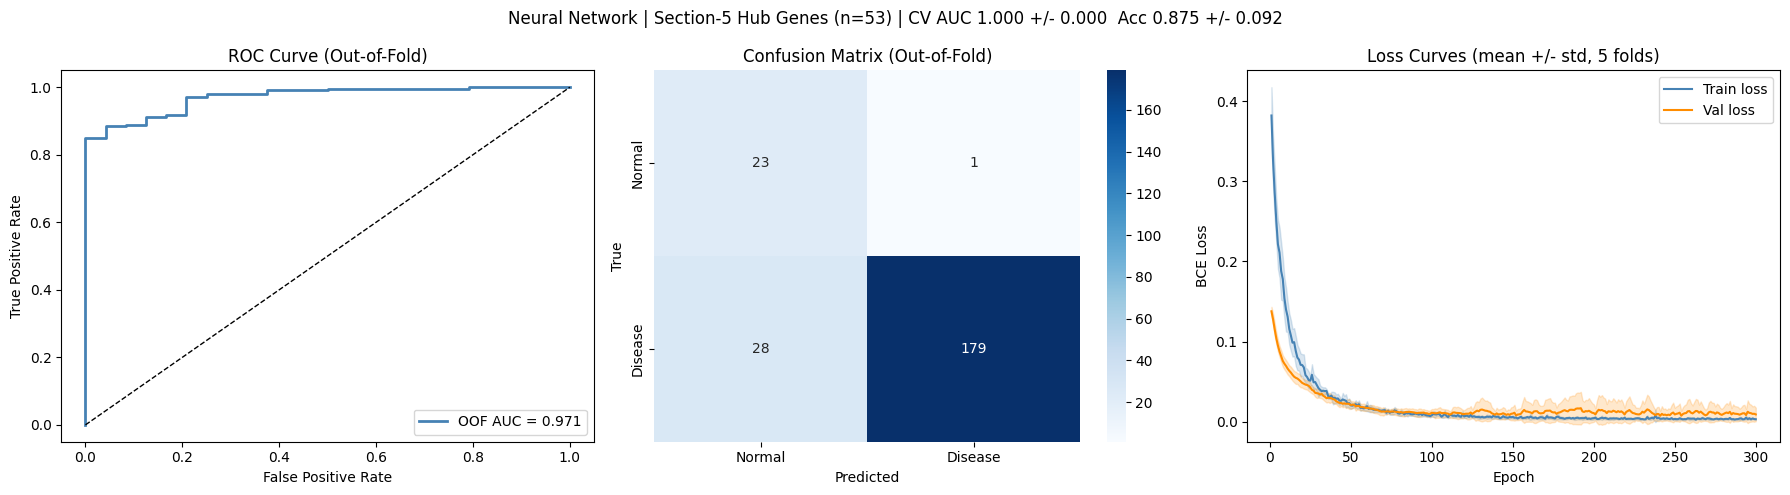

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve (out-of-fold)
fpr, tpr, _ = roc_curve(all_true, all_probs)
oof_auc = roc_auc_score(all_true, all_probs)
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"OOF AUC = {oof_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (Out-of-Fold)")
axes[0].legend()

# Confusion matrix (out-of-fold)
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal", "Disease"],
            yticklabels=["Normal", "Disease"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (Out-of-Fold)")

# Loss curves (mean +/- std across folds)
tl_arr = np.array(all_train_losses)
vl_arr = np.array(all_val_losses)
ep = range(1, tl_arr.shape[1] + 1)
axes[2].plot(ep, tl_arr.mean(0), color="steelblue", label="Train loss")
axes[2].fill_between(ep, tl_arr.mean(0)-tl_arr.std(0), tl_arr.mean(0)+tl_arr.std(0), alpha=0.2, color="steelblue")
axes[2].plot(ep, vl_arr.mean(0), color="darkorange", label="Val loss")
axes[2].fill_between(ep, vl_arr.mean(0)-vl_arr.std(0), vl_arr.mean(0)+vl_arr.std(0), alpha=0.2, color="darkorange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("BCE Loss")
axes[2].set_title("Loss Curves (mean +/- std, 5 folds)")
axes[2].legend()

plt.suptitle(
    f"Neural Network | Section-5 Hub Genes (n={len(hub_genes)}) | "
    f"CV AUC {np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs):.3f}  "
    f"Acc {np.mean(fold_accs):.3f} +/- {np.std(fold_accs):.3f}",
    fontsize=12)
plt.tight_layout()
plt.show()